**Set environment**

In [1]:
import numpy     as np
import pandas    as pd
import itertools as it
import pickle
import os

from Bio import SeqIO
import logomaker as lm

import seaborn as sns
import matplotlib.pyplot as plt

import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed

In [2]:
%run ../run_config_project.py
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data


You are working with      IGVF BlueSTARR
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references



## Import fasta data

**Check data existence**

In [3]:
%env FD_RES={FD_RES}

env: FD_RES=/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results


In [4]:
%%bash
echo  ${FD_RES}
echo
FDIRY=${FD_RES}/analysis_variant_motif_richard
ls -1 ${FDIRY}/*flankL35R70* | xargs -n 1 basename

/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results

variant_closed_gof_bluestarr_flankL35R70_obs.fa
variant_closed_gof_bluestarr_flankL35R70_ref.fa
variant_closed_gof_bluestarr_flankL35R70_unobs.fa
variant_closed_gof_bluestarr_withseq_flankL35R70.tsv.gz


In [5]:
%%bash
echo  ${FD_RES}
echo
FDIRY=${FD_RES}/analysis_variant_motif_richard/batches_dev
ls -1 ${FDIRY}/*flankL35R70* | xargs -n 1 basename

/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results

variant_closed_gof_bluestarr_flankL35R70_dev10000_obs.fa
variant_closed_gof_bluestarr_flankL35R70_dev10000_ref.fa
variant_closed_gof_bluestarr_flankL35R70_dev10000_unobs.fa
variant_closed_gof_bluestarr_flankL35R70_dev1000_obs.fa
variant_closed_gof_bluestarr_flankL35R70_dev1000_ref.fa
variant_closed_gof_bluestarr_flankL35R70_dev1000_unobs.fa
variant_closed_gof_bluestarr_flankL35R70_dev100_obs.fa
variant_closed_gof_bluestarr_flankL35R70_dev100_ref.fa
variant_closed_gof_bluestarr_flankL35R70_dev100_unobs.fa


**Import data**

In [26]:
### set file directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard", "batches_dev")

txt_fpath_ref = os.path.join(txt_fdiry, "variant_closed_gof_bluestarr_flankL35R70_dev100_ref.fa")
txt_fpath_obs = os.path.join(txt_fdiry, "variant_closed_gof_bluestarr_flankL35R70_dev100_obs.fa")
txt_fpath_ubs = os.path.join(txt_fdiry, "variant_closed_gof_bluestarr_flankL35R70_dev100_unobs.fa")

### import data
lst_seq_record_ref = list(SeqIO.parse(txt_fpath_ref, "fasta"))
lst_seq_record_obs = list(SeqIO.parse(txt_fpath_obs, "fasta"))
lst_seq_record_ubs = list(SeqIO.parse(txt_fpath_ubs, "fasta"))

**check imported data**

In [27]:
print(type(lst_seq_record_ref[0]))

<class 'Bio.SeqRecord.SeqRecord'>


In [32]:
for lst in [lst_seq_record_ref, lst_seq_record_obs, lst_seq_record_ubs]:
    tmp = lst[0]
    print(tmp)
    print(tmp.id)
    print(tmp.seq)
    print()

ID: chr4:74487586:A:G:C
Name: chr4:74487586:A:G:C
Description: chr4:74487586:A:G:C
Number of features: 0
Seq('ACATGTGTGTATGCTTGTCTATATACACTGTATGAAGCAAGAGGAGAAAATACT...TTG')
chr4:74487586:A:G:C
ACATGTGTGTATGCTTGTCTATATACACTGTATGAAGCAAGAGGAGAAAATACTCATGAATTCTAGGAACTGTAGAATGAAGGAGGGATTTATGTGGGACACATTG
ID: chr4:74487586:A:G:C
Name: chr4:74487586:A:G:C
Description: chr4:74487586:A:G:C
Number of features: 0
Seq('ACATGTGTGTATGCTTGTCTATATACACTGTATGAGGTAGAATGAAGGAGGGAT...TTG')
chr4:74487586:A:G:C
ACATGTGTGTATGCTTGTCTATATACACTGTATGAGGTAGAATGAAGGAGGGATTTATGTGGGACACATTG
ID: chr4:74487586:A:G:C
Name: chr4:74487586:A:G:C
Description: chr4:74487586:A:G:C
Number of features: 0
Seq('ACATGTGTGTATGCTTGTCTATATACACTGTATGACGTAGAATGAAGGAGGGAT...TTG')
chr4:74487586:A:G:C
ACATGTGTGTATGCTTGTCTATATACACTGTATGACGTAGAATGAAGGAGGGATTTATGTGGGACACATTG


In [9]:
print(lst_seq_record_obs[0])

ID: chr4:74487586:A:G:C
Name: chr4:74487586:A:G:C
Description: chr4:74487586:A:G:C
Number of features: 0
Seq('ACATGTGTGTATGCTTGTCTATATACACTGTATGAGGTAGAATGAAGGAGGGAT...TTG')


In [10]:
print(lst_seq_record_unobs[0])

ID: chr4:74487586:A:G:C
Name: chr4:74487586:A:G:C
Description: chr4:74487586:A:G:C
Number of features: 0
Seq('ACATGTGTGTATGCTTGTCTATATACACTGTATGACGTAGAATGAAGGAGGGAT...TTG')


In [11]:
### check data
assert len(lst_seq_record_ref) == len(lst_seq_record_obs) == len(lst_seq_record_unobs)
num_total = len(lst_seq_record_ref)
print("Total variants:", num_total)

Total variants: 100


In [12]:
lst = [rec.id for rec in lst_seq_record_ref]
lst[:10]

['chr4:74487586:A:G:C',
 'chr9:135685432:G:G:C',
 'chr1:173251490:G:G:C',
 'chr1:147523391:G:G:C',
 'chr18:54580749:A:G:T',
 'chr7:80949454:A:G:C',
 'chr15:42051620:A:G:C',
 'chr6:126250573:G:G:T',
 'chr2:6818290:C:C:G',
 'chr8:1743502:G:G:T']

## Import motif data

In [22]:
### set file directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard")
txt_fname = "JASPAR2024_CORE_vertebrates_non-redundant.lods.pkl"
txt_fpath = os.path.join(txt_fdiry, txt_fname)

### import data
#obj = np.load(txt_fpath, allow_pickle=True)
with open(txt_fpath, "rb") as f:
    obj = pickle.load(f)
    
print("Object dictionary keys:")
for txt in obj.keys():
    print(txt)
print()

### assign and show
dct_motif_lods = obj["lods"]
print(f"Loaded LODS for {len(dct_motif_lods)} motifs from {txt_fpath}\n")

print("List of motifs:")
tmp = it.islice(dct_motif_lods.keys(), 10)
for txt in tmp:
    print(txt)

Object dictionary keys:
pwms
lods
bg
names
alphabet

Loaded LODS for 879 motifs from /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/JASPAR2024_CORE_vertebrates_non-redundant.lods.pkl

List of motifs:
MA0002.3 Runx1
MA0003.5 TFAP2A
MA0004.1 Arnt
MA0006.2 Ahr::Arnt
MA0007.4 Ar
MA0009.2 TBXT
MA0014.4 PAX5
MA0017.3 NR2F1
MA0018.5 CREB1
MA0019.2 Ddit3::Cebpa


In [23]:
### set file directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard")
txt_fname = "JASPAR2024_CORE_vertebrates_non-redundant.pmap.pkl"
txt_fpath = os.path.join(txt_fdiry, txt_fname)

### import data
with open(txt_fpath, "rb") as f:
    dct_motif_model = pickle.load(f)  # motif_name → {Tbind, cdf, ccdf, grid, ...}
print(f"Loaded PMAPs for {len(dct_motif_model)} motifs from {txt_fpath}\n")

### show data
print("List of motifs:")
for txt in it.islice(dct_motif_model.keys(), 10):
    print(txt)

Loaded PMAPs for 879 motifs from /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/JASPAR2024_CORE_vertebrates_non-redundant.pmap.pkl

List of motifs:
MA0004.1 Arnt
MA0006.2 Ahr::Arnt
MA0002.3 Runx1
MA0009.2 TBXT
MA0007.4 Ar
MA0019.2 Ddit3::Cebpa
MA0018.5 CREB1
MA0014.4 PAX5
MA0003.5 TFAP2A
MA0024.3 E2F1


**Show imported data**

In [24]:
print(dct_motif_lods["MA0002.3 Runx1"])

[[ -2.33678411   1.51292395  -1.34160442   0.06893956]
 [ -3.4464086  -17.51894952  -5.75341802   1.6302508 ]
 [-18.2450829   -2.32434655   2.30959178  -3.56069199]
 [ -2.83635512  -1.56448055  -2.43148993   1.4562214 ]
 [-18.2450829  -17.51894952   2.39560322  -5.58817272]
 [ -5.19183577  -3.16084782   2.2909761   -2.74945363]
 [ -5.95737052   0.09069095  -0.58922939   1.0983278 ]
 [ -2.24587561   0.30170314  -2.22092294   1.0831642 ]
 [ -0.31351433  -1.24938449  -0.38584726   0.75167728]]


In [25]:
arr = np.array([lods.shape[0] for lods in dct_motif_lods.values()])
res = np.array([np.min(arr), np.mean(arr), np.median(arr), np.max(arr)])
res = np.round(res, 2)
print(res)

[ 5.   10.09  9.   33.  ]


In [26]:
tmp = dct_motif_model["MA0002.3 Runx1"].keys()
for txt in tmp:
    print(txt)

arr_num_score_grid
arr_num_score_pmf
arr_num_score_ccdf
arr_lod_WxB
num_Tbind
num_alpha
num_precision


In [27]:
print(dct_motif_model["MA0002.3 Runx1"]["arr_lod_WxB"])

[[ -2.33678411   1.51292395  -1.34160442   0.06893956]
 [ -3.4464086  -17.51894952  -5.75341802   1.6302508 ]
 [-18.2450829   -2.32434655   2.30959178  -3.56069199]
 [ -2.83635512  -1.56448055  -2.43148993   1.4562214 ]
 [-18.2450829  -17.51894952   2.39560322  -5.58817272]
 [ -5.19183577  -3.16084782   2.2909761   -2.74945363]
 [ -5.95737052   0.09069095  -0.58922939   1.0983278 ]
 [ -2.24587561   0.30170314  -2.22092294   1.0831642 ]
 [ -0.31351433  -1.24938449  -0.38584726   0.75167728]]


## Helper function

In [28]:
from numpy.lib.stride_tricks import sliding_window_view

from motifdelta.encode import one_hot_encode
from motifdelta.rc     import reverse_complement_matrix

In [45]:
# --- Pad motif LLRs to the same width (right-pad with zeros) ---
def pad_motifs_to_max(dct_lods, alphabet="ACGT"):
    """
    dct_lods: dict {motif_name: arr_lod (W,4)}
    returns:
      names: list[str]
      arr_kern: (M, W_max, 4) float32
      widths: (M,) original widths
      W_max: int
    """
    names = list(dct_lods.keys())
    widths = np.array([dct_lods[n].shape[0] for n in names], dtype=int)
    W_max = int(widths.max())
    M = len(names)
    arr_kern = np.zeros((M, W_max, 4), dtype=np.float32)
    for i, n in enumerate(names):
        W = widths[i]
        K = dct_lods[n].astype(np.float32, copy=False)
        # right-pad zeros
        arr_kern[i, :W, :] = K
    return names, arr_kern, widths, W_max

# --- Scan all motifs at once on CPU (forward OR reverse kernels) ---
def scan_all_motifs(arr_seq, arr_kern):
    """
    arr_seq : np.ndarray (L, 4)
    arr_kern: np.ndarray (M, W_max, 4)
    returns : np.ndarray (M, Npos)
    """
    ###
    W = arr_kern.shape[1]
    
    # build sliding windows: (P, W, 4)
    arr_win = np.lib.stride_tricks.sliding_window_view(arr_seq, (W, 4)).reshape(-1, W, 4)
    
    # einsum over window positions and motif kernels
    arr_score = np.einsum('nwc,mwc->mn', arr_win, arr_kern, optimize=True)
    return arr_score

# --- 4) Sequence-level scanner returning your usual nested dict (but Npos-length vectors)
def scan_one_sequence(idx, txt_seq, arr_motif_fwd_MxWxB, arr_motif_rev_MxWxB):
    """
    [forward, reverse]
    """
    arr_seq = one_hot_encode(txt_seq, txt_alphabet="ACGT")  # (L, 4)
    L = arr_seq.shape[0]
    W = arr_motif_fwd_MxWxB.shape[1]
    if L < W:
        raise ValueError(f"Sequence shorter ({L}) than largest motif width ({W}).")

    arr_score_fwd = scan_all_motifs(arr_seq, arr_motif_fwd_MxWxB)  # (M, Npos)
    arr_score_rev = scan_all_motifs(arr_seq, arr_motif_rev_MxWxB)  # (M, Npos)
    arr_score_out = np.stack([arr_score_fwd, arr_score_rev], axis=-1).astype(np.float32)  # (M, Npos, 2)
    return idx, arr_score_out
    
# --- 5) Parallel wrapper (same pattern as your current parallel code)
def scan_sequence_batch_parallel(lst_seq_txt, arr_motif_fwd_MxWxB, arr_motif_rev_MxWxB, num_workers=None):
    ###
    if num_workers is None:
        num_workers = 1
        #num_workers = max(1, multiprocessing.cpu_count() - 1)

    ### Dimension:
    ###     input sequence (N, L, B)
    ###     input motif (M, W, B)
    ###     output score (N, M, P, 2) where P = L - W + 1
    N = len(lst_seq_txt)
    L = len(lst_seq_txt[0])
    M = arr_motif_fwd_MxWxB.shape[0]
    W = arr_motif_fwd_MxWxB.shape[1]
    P = L - W + 1
    arr_out = np.empty((N, M, P, 2), dtype=np.float32)
    
    ###
    with ProcessPoolExecutor(max_workers=num_workers) as exe:
        lst = [
            exe.submit(
                scan_one_sequence, 
                idx, lst_seq_txt[idx], 
                arr_motif_fwd_MxWxB, 
                arr_motif_rev_MxWxB
            )
            for idx in range(N)
        ]
        for f in as_completed(lst):
            idx, arr = f.result()
            arr_out[idx] = arr
            
    return arr_out

In [46]:
lst_motif_name, arr_motif_lods_fwd, arr_motif_width, num_w_max = pad_motifs_to_max(dct_motif_lods)
arr_motif_lods_rev = reverse_complement_matrix(arr_motif_lods_fwd)

print(arr_motif_lods_fwd.shape)
print(arr_motif_lods_rev.shape)
print(arr_motif_width.shape)

(879, 33, 4)
(879, 33, 4)
(879,)


In [47]:
### convert Biopython records to strings
lst_seq_txt_idx = [str(rec.id)  for rec in lst_seq_record_ref]
lst_seq_txt_ref = [str(rec.seq) for rec in lst_seq_record_ref]
lst_seq_txt_obs = [str(rec.seq) for rec in lst_seq_record_obs]
lst_seq_txt_ubs = [str(rec.seq) for rec in lst_seq_record_ubs]

In [63]:
%%time

arr_motif_scan_ref = scan_sequence_batch_parallel(lst_seq_txt_ref, arr_motif_lods_fwd, arr_motif_lods_rev, num_workers=10)
arr_motif_scan_obs = scan_sequence_batch_parallel(lst_seq_txt_obs, arr_motif_lods_fwd, arr_motif_lods_rev, num_workers=10)
arr_motif_scan_ubs = scan_sequence_batch_parallel(lst_seq_txt_ubs, arr_motif_lods_fwd, arr_motif_lods_rev, num_workers=10)

print(arr_motif_scan_ref.shape)
print(arr_motif_scan_obs.shape)
print(arr_motif_scan_ubs.shape)

arr_motif_scan_ref = arr_motif_scan_ref[:,:,:71,:]
arr_motif_scan_obs = arr_motif_scan_obs[:,:,:71,:]
arr_motif_scan_ubs = arr_motif_scan_ubs[:,:,:71,:]

print(arr_motif_scan_ref.shape)
print(arr_motif_scan_obs.shape)
print(arr_motif_scan_ubs.shape)

(100, 879, 74, 2)
(100, 879, 74, 2)
(100, 879, 74, 2)
(100, 879, 71, 2)
(100, 879, 71, 2)
(100, 879, 71, 2)
CPU times: user 459 ms, sys: 2.41 s, total: 2.87 s
Wall time: 5.05 s


## Visualize motif scanning scores

In [64]:
txt_seq_ref = lst_seq_txt_ref[0]
txt_seq_obs = lst_seq_txt_obs[0]
txt_seq_ubs = lst_seq_txt_ubs[0]

print(txt_seq_ref == txt_seq_obs)     # should be True except one base
print(txt_seq_ref == txt_seq_ubs)   # should be True except one base
print(txt_seq_ref)
print(txt_seq_obs)
print(txt_seq_unobs)

False
False
ACATGTGTGTATGCTTGTCTATATACACTGTATGAAGCAAGAGGAGAAAATACTCATGAATTCTAGGAACTGTAGAATGAAGGAGGGATTTATGTGGGACACATTG
ACATGTGTGTATGCTTGTCTATATACACTGTATGAGGCAAGAGGAGAAAATACTCATGAATTCTAGGAACTGTAGAATGAAGGAGGGATTTATGTGGGACACATTG
ACATGTGTGTATGCTTGTCTATATACACTGTATGACGCAAGAGGAGAAAATACTCATGAATTCTAGGAACTGTAGAATGAAGGAGGGATTTATGTGGGACACATTG


In [65]:
###
txt_motif_target = "MA0099.4 FOS::JUN"
num_motif_idx    = lst_motif_name.index(txt_motif_target)
num_seq_idx      = 0
txt_seq_idx      = lst_seq_txt_idx[num_seq_idx]
num_strand_idx   = 0 # forward
print("Motif Name: ", txt_motif_target)
print("Motif Index:", num_motif_idx)

###
arr_score_obs   = arr_motif_scan_obs[num_seq_idx, num_motif_idx, :, num_strand_idx]
arr_score_ubs   = arr_motif_scan_ubs[num_seq_idx, num_motif_idx, :, num_strand_idx]
arr_score_delta = arr_score_ubs - arr_score_obs

Motif Name:  MA0099.4 FOS::JUN
Motif Index: 67


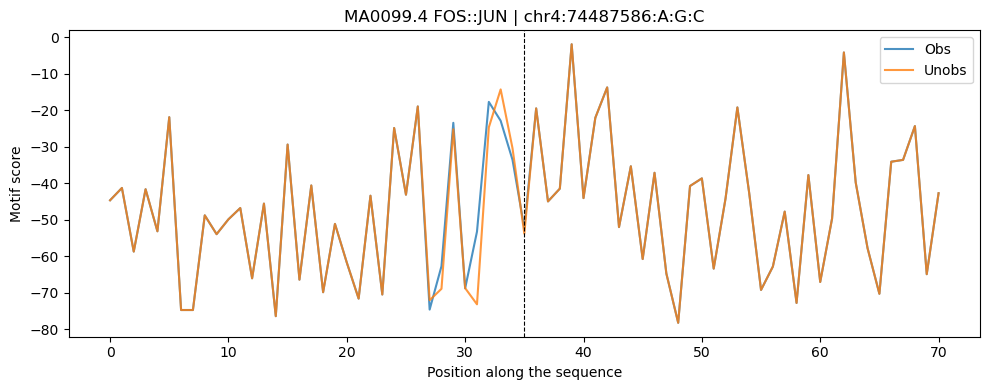

In [66]:
###
plt.figure(figsize=(10,4))
plt.plot(arr_score_obs, label="Obs",   alpha=0.8)
plt.plot(arr_score_ubs, label="Unobs", alpha=0.8)
plt.axvline(35, color="k", linestyle="--", lw=0.8)
plt.legend()
plt.title(f"{txt_motif_target} | {txt_seq_idx}")
plt.xlabel("Position along the sequence")
plt.ylabel("Motif score")
plt.tight_layout()
plt.show()

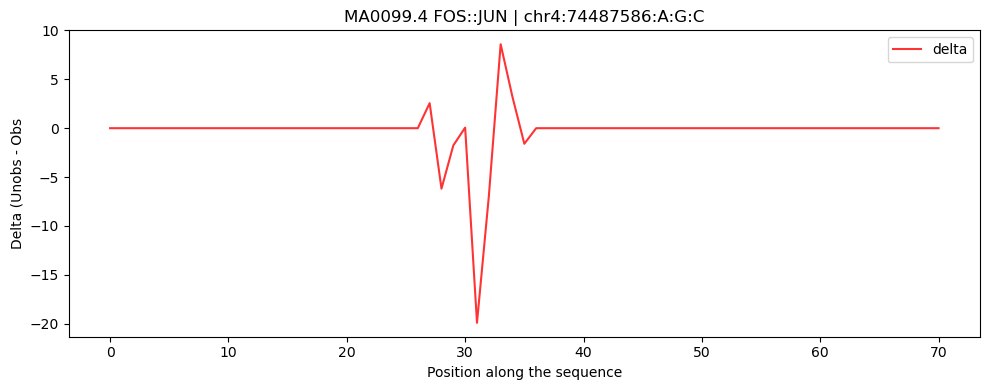

In [67]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(arr_score_delta, label="delta", alpha=0.8, c = "red")
plt.legend()
plt.title(f"{txt_motif_target} | {txt_seq_idx}")
plt.xlabel("Position along the sequence")
plt.ylabel("Delta (Unobs - Obs")
plt.tight_layout()
plt.show()

## Tbind scores

In [1]:
txt_motif = "MA0099.4 FOS::JUN"
dct_model = dct_motif_model[txt_motif]

### Extract arrays
arr_num_score_grid = dct_model["arr_num_score_grid"] # x-axis (score values)
arr_num_score_pmf  = dct_model["arr_num_score_pmf"]  # y-axis (probabilities)
num_Tbind = dct_model["num_Tbind"]         # threshold score
num_alpha = dct_model["num_alpha"]         # tail probability
num_precision = dct_model["num_precision"] # discretization

print(f"{txt_motif} - grid: {arr_num_score_grid.shape}, pmf: {arr_num_score_pmf.shape}")
print(f"Tbind = {num_Tbind:.3f}, α = {num_alpha}, precision = {num_precision}")

NameError: name 'dct_motif_model' is not defined

In [ ]:
# Extract grid (x-axis) and CCDF (y-axis)
grid = d.get("grid", None)
ccdf = d.get("ccdf", None)

if grid is None or ccdf is None:
    raise ValueError(f"Motif {motif} missing 'grid' or 'ccdf' in PMAP data.")

# Extract Tbind (threshold score)
Tbind = d.get("num_Tbind", np.nan)

plt.figure(figsize=(7, 5))
plt.plot(grid, ccdf, label="P(S ≥ score)", lw=2)
plt.axvline(Tbind, color="red", ls="--", lw=1.5, label=f"Tbind = {Tbind:.2f}")
plt.yscale("log")
plt.xlabel("Motif log-odds score (bits)")
plt.ylabel("Tail probability P(S ≥ score)")
plt.title(f"PMAP distribution — {motif}")
plt.legend()
plt.tight_layout()
plt.show()

## Compute raw and weighted Δ using Tbind

In [73]:
### raw delta (unobs - obs)
arr_motif_delta = arr_motif_scan_ubs - arr_motif_scan_obs
print("Delta Shape:", arr_motif_delta.shape)

Delta Shape: (100, 879, 71, 2)


**Logistic weighting function**

$$\Delta = \text{score}_\text{unobs} - \text{score}_\text{obs}$$
$$\Delta w = \Delta \times w$$
$$w = \frac{1}{1 + \exp \{ -(\text{score}_\text{max} - T_\text{bind}) \} }$$

In [59]:
def logistic_weight(x, T, k=1.0):
    """Compute sigmoid-like logistic weight."""
    z = -(x - T) / k
    z = np.clip(z, -60, 60)  # avoid overflow
    return 1.0 / (1.0 + np.exp(z))

In [69]:
lst_motif_name = list(dct_motif_model.keys())
arr_Tbind = np.array([dct_motif_model[txt]["num_Tbind"] for txt in lst_motif_name])

print(f"Tbind range: {np.nanmin(arr_Tbind):.3f} – {np.nanmax(arr_Tbind):.3f}")

Tbind range: -2.329 – 16.667


In [94]:
# --- get absolute max motif scores (per motif, per position) ---
arr_motif_strength = np.maximum(arr_motif_scan_obs, arr_motif_scan_ubs)
print(f"Score_max shape: {arr_motif_strength.shape}")

# --- broadcast Tbind to match shape ---
arr_Tbind_reshape = arr_Tbind[None, :, None, None]  # (1, M, 1, 1)
print(f"Tbind shape: {arr_Tbind_reshape.shape}")

# --- compute weights ---
arr_motif_weight = logistic_weight(arr_motif_strength, arr_Tbind_reshape)
print(f"w shape: {arr_motif_weight.shape}")

# --- weighted Δ ---
arr_motif_delta_weighted = arr_motif_delta * arr_motif_weight

print(f"Δw shape: {arr_motif_delta_weighted.shape}")

Score_max shape: (100, 879, 71, 2)
Tbind shape: (1, 879, 1, 1)
w shape: (100, 879, 71, 2)
Δw shape: (100, 879, 71, 2)


In [95]:
print(np.isnan(arr_motif_delta).all())
print(np.nanmin(arr_motif_delta), np.nanmax(arr_motif_delta))

False
-20.75 20.75


In [96]:
print(np.isnan(arr_motif_weight).all())
print(np.nanmin(arr_motif_weight), np.nanmax(arr_motif_weight))

False
8.75651076269652e-27 0.9999999970126376


In [97]:
motif = "MA0099.4 FOS::JUN"
idx_motif  = lst_motif_name.index(motif)
idx_strand = 0  # 0 = forward, 1 = reverse
idx_seq    = 0   # first sequence for demo

x  = np.arange(71) - 35  # variant-centered coordinates
d  = arr_motif_delta[ idx_seq, idx_motif, :, idx_strand]
w  = arr_motif_weight[idx_seq, idx_motif, :, idx_strand]
dw = arr_motif_delta_weighted[idx_seq, idx_motif, :, idx_strand]

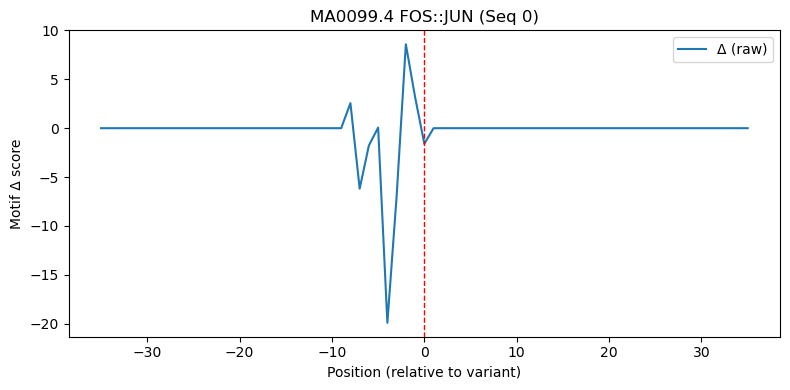

In [98]:
plt.figure(figsize=(8,4))
plt.plot(x, d, label="Δ (raw)", lw=1.5)
plt.axvline(0, color="red", ls="--", lw=1)
plt.title(f"{motif} (Seq {i_seq})")
plt.xlabel("Position (relative to variant)")
plt.ylabel("Motif Δ score")
plt.legend()
plt.tight_layout()
plt.show()

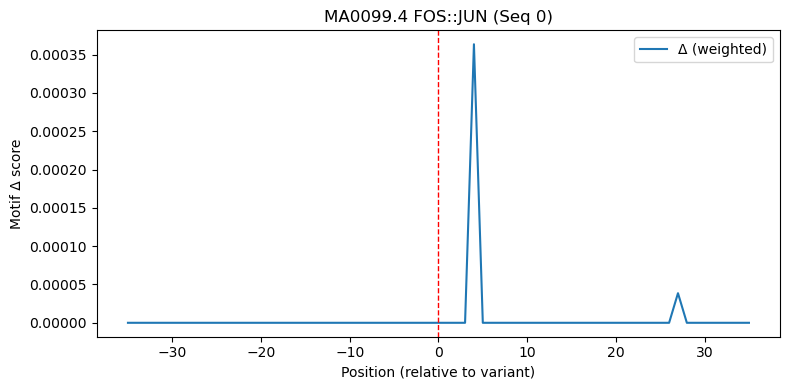

In [99]:
plt.figure(figsize=(8,4))
plt.plot(x, w, label="Δ (weighted)", lw=1.5)
plt.axvline(0, color="red", ls="--", lw=1)
plt.title(f"{motif} (Seq {i_seq})")
plt.xlabel("Position (relative to variant)")
plt.ylabel("Motif Δ score")
plt.legend()
plt.tight_layout()
plt.show()

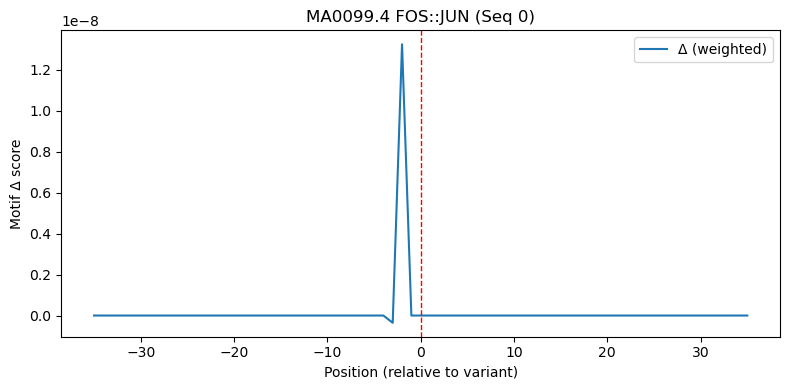

In [100]:
plt.figure(figsize=(8,4))
plt.plot(x, dw, label="Δ (weighted)", lw=1.5)
plt.axvline(0, color="red", ls="--", lw=1)
plt.title(f"{motif} (Seq {i_seq})")
plt.xlabel("Position (relative to variant)")
plt.ylabel("Motif Δ score")
plt.legend()
plt.tight_layout()
plt.show()